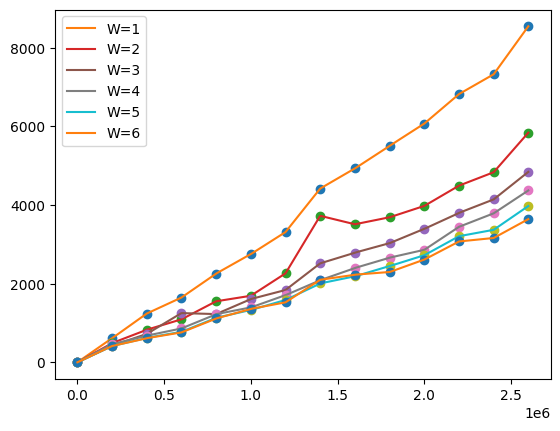

14


In [1]:
import json 
import glob
import matplotlib.pyplot as plt
from numpy import linspace
from math import sqrt
from scipy.interpolate import interp1d

def get_data(file_name):
    fh = open(file_name)
    data = json.load(fh)
    fh.close()
    return data

def mean_value(values):
    return sum(values)/len(values)

def std_dev(values, mean):
    return sqrt(sum([(val-mean)**2 for val in values])/len(values))

f_names = glob.glob("results/Workers/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['NUMBER_OF_WORKER_PODS'])
var_workers = [{'w' : d['environment']['NUMBER_OF_WORKER_PODS'],
            'ins': [{'length': float(key),
                     'mean': mean_value([dic['duration'] for dic in d['result'][key]]),
                     'std_dev': std_dev([dic['duration'] for dic in d['result'][key]],mean_value([dic['duration'] for dic in d['result'][key]]))
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

def get_list(ins, key):
    return [entry[key] for entry in ins]

for met in var_workers:
    x = [0]+get_list(met['ins'],'length')
    y = [0]+get_list(met['ins'],'mean')
    f = interp1d(x, y, kind='linear')

    ax = linspace(0, max(x) , 600)
    fy = f(ax)
    plt.plot(x, y, 'o')
    plt.plot(ax, fy, '-', label = 'W='+str(met['w']))
    plt.legend(loc="upper left")

plt.savefig('results/Workers/means.png')
plt.show()
print(len(y))
plt.close()


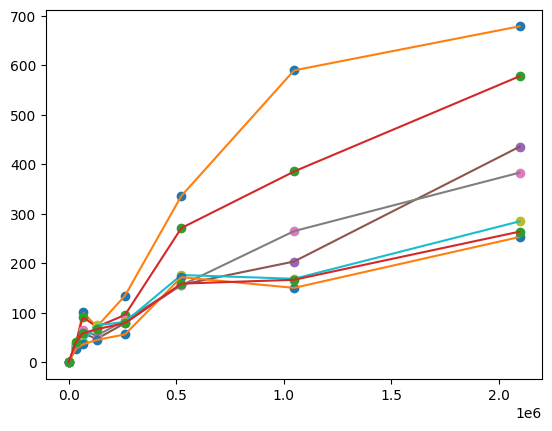

In [2]:

for met in var_workers:
    x = [0]+get_list(met['ins'],'length')
    y = [0]+get_list(met['ins'],'std_dev')
    f = interp1d(x, y, kind='linear')

    ax = linspace(0, 2097152.0 , 300)
    fy = f(ax)
    plt.plot(x, y, 'o', ax, fy, '-')

plt.savefig('results/Workers/std_devs.png')
plt.show()
plt.close()

In [2]:
import json 
import glob
import matplotlib.pyplot as plt
from numpy import linspace
from math import sqrt
from scipy.interpolate import interp1d

def get_data(file_name):
    fh = open(file_name)
    data = json.load(fh)
    fh.close()
    return data

def mean_value(values):
    return sum(values)/len(values)

def std_dev(values, mean):
    return sqrt(sum([(val-mean)**2 for val in values])/len(values))

f_names = glob.glob("results/Blocks/Incremental*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['NUMBER_OF_BLOCKS'])
var_blocks = [{'K' : d['environment']['NUMBER_OF_BLOCKS'],
            'ins': [{'length': float(key),
                     'mean': mean_value([dic['duration'] for dic in d['result'][key]]),
                     'std_dev': std_dev([dic['duration'] for dic in d['result'][key]],mean_value([dic['duration'] for dic in d['result'][key]]))
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

def get_list(ins, key):
    return [entry[key] for entry in ins]

for met in var_blocks:
    x = [0]+get_list(met['ins'],'length')
    y = [0]+get_list(met['ins'],'mean')
    f = interp1d(x, y, kind='linear')

    ax = linspace(0, max(x) , 600)
    fy = f(ax)
    plt.plot(x, y, 'o')
    plt.plot(ax, fy, '-', label = 'K='+str(met['K']))
    plt.legend(loc="upper left")

plt.savefig('results/Blocks/Blocks_means.png')
plt.show()
print(len(y))
plt.close()


<Figure size 640x480 with 0 Axes>

14


In [ ]:

for met in var_blocks:
    x = [0]+get_list(met['ins'],'length')
    y = [0]+get_list(met['ins'],'std_dev')
    f = interp1d(x, y, kind='linear')

    ax = linspace(0, 2097152.0 , 300)
    fy = f(ax)
    plt.plot(x, y, 'o', ax, fy, '-')

plt.savefig('results/Blocks/Blocks_std_devs.png')
plt.show()
plt.close()

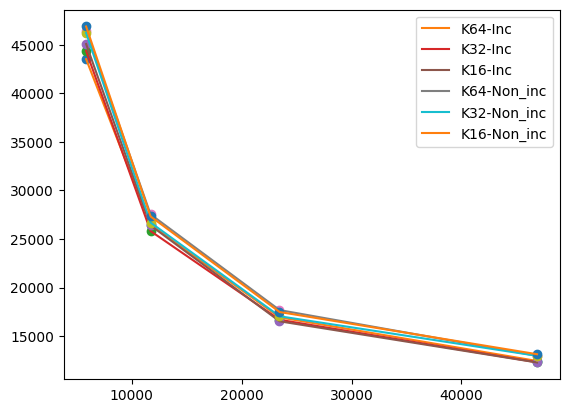

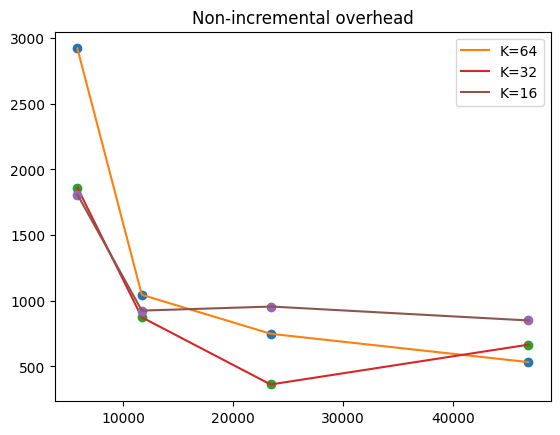

In [7]:
import json 
import glob
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
from scipy.interpolate import interp1d

def get_data(file_name):
    fh = open(file_name)
    data = json.load(fh)
    fh.close()
    return data

def mean_value(values):
    return sum(values)/len(values)

def std_dev(values, mean):
    return sqrt(sum([(val-mean)**2 for val in values])/len(values))

def estimation(fail_ratios,durations):
    x=np.array(np.log2(fail_ratios))
    y=np.array(durations)
    coefs = np.polyfit(x, y, deg=1)
    return coefs[1]+ coefs[0]*(np.log2(.5))

def fail_ratio(dic):
    return dic['statistics']['failure']['total']/(dic['statistics']['failure']['total']+len([x for x in dic['statistics']['success']['durations'] if x !=0]))

f_names = glob.glob("Var_threshold_100ms/K64/Incremental/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['MAX_LEN'])
var_threshold = {'K64-Inc': [{'threshold' : d['environment']['MAX_LEN'],
            'ins': [{'length': float(key),
                     'estimation': estimation([fail_ratio(dic) for dic in d['result'][key]], [dic['duration'] for dic in d['result'][key]]) 
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]}

f_names = glob.glob("Var_threshold_100ms/K32/Incremental/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['MAX_LEN'])
var_threshold['K32-Inc'] = [{'threshold' : d['environment']['MAX_LEN'],
            'ins': [{'length': float(key),
                     'estimation': estimation([fail_ratio(dic) for dic in d['result'][key]], [dic['duration'] for dic in d['result'][key]]) 
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

f_names = glob.glob("Var_threshold_100ms/K16/Incremental/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['MAX_LEN'])
var_threshold['K16-Inc'] = [{'threshold' : d['environment']['MAX_LEN'],
            'ins': [{'length': float(key),
                     'estimation': estimation([fail_ratio(dic) for dic in d['result'][key]], [dic['duration'] for dic in d['result'][key]]) 
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

f_names = glob.glob("Var_threshold_100ms/K64/Non-incremental/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['MAX_LEN'])
var_threshold['K64-Non_inc'] = [{'threshold' : d['environment']['MAX_LEN'],
            'ins': [{'length': float(key),
                     'estimation': estimation([fail_ratio(dic) for dic in d['result'][key]], [dic['duration'] for dic in d['result'][key]]) 
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

f_names = glob.glob("Var_threshold_100ms/K32/Non-incremental/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['MAX_LEN'])
var_threshold['K32-Non_inc'] = [{'threshold' : d['environment']['MAX_LEN'],
            'ins': [{'length': float(key),
                     'estimation': estimation([fail_ratio(dic) for dic in d['result'][key]], [dic['duration'] for dic in d['result'][key]]) 
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

f_names = glob.glob("Var_threshold_100ms/K16/Non-incremental/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['MAX_LEN'])
var_threshold['K16-Non_inc'] = [{'threshold' : d['environment']['MAX_LEN'],
            'ins': [{'length': float(key),
                     'estimation': estimation([fail_ratio(dic) for dic in d['result'][key]], [dic['duration'] for dic in d['result'][key]]) 
                    } for key in list(d['result']) if key != 'redeployment']} for d in tests]

for key, met in var_threshold.items():
    x = [inst['threshold'] for inst in met]
    y = [inst['ins'][0]['estimation'] for inst in met]
    f = interp1d(x, y, kind='linear')

    ax = np.linspace(5860, max(x) , 600)
    fy = f(ax)
    plt.plot(x, y, 'o')
    plt.plot(ax, fy, '-', label = key)

plt.legend(loc="upper right")

plt.savefig('Var_threshold/curve.png')
plt.show()
plt.close()

x = [inst['threshold'] for inst in var_threshold['K64-Inc']]
y = [ninc['ins'][0]['estimation']-inc['ins'][0]['estimation'] for inc, ninc in zip(var_threshold['K64-Inc'],var_threshold['K64-Non_inc'])]
f = interp1d(x, y, kind='linear')
ax = np.linspace(5860, max(x) , 600)
fy = f(ax)
plt.title('Non-incremental overhead')
plt.plot(x, y, 'o')
plt.plot(ax, fy, '-', label = 'K=64')
y = [ninc['ins'][0]['estimation']-inc['ins'][0]['estimation'] for inc, ninc in zip(var_threshold['K32-Inc'],var_threshold['K32-Non_inc'])]
f = interp1d(x, y, kind='linear')
ax = np.linspace(5860, max(x) , 600)
fy = f(ax)
plt.plot(x, y, 'o')
plt.plot(ax, fy, '-', label = 'K=32')
y = [ninc['ins'][0]['estimation']-inc['ins'][0]['estimation'] for inc, ninc in zip(var_threshold['K16-Inc'],var_threshold['K16-Non_inc'])]
f = interp1d(x, y, kind='linear')
ax = np.linspace(5860, max(x) , 600)
fy = f(ax)
plt.plot(x, y, 'o')
plt.plot(ax, fy, '-', label = 'K=16')
plt.legend(loc="upper right")
plt.savefig('Var_threshold/delta.png')
plt.show()
plt.close()

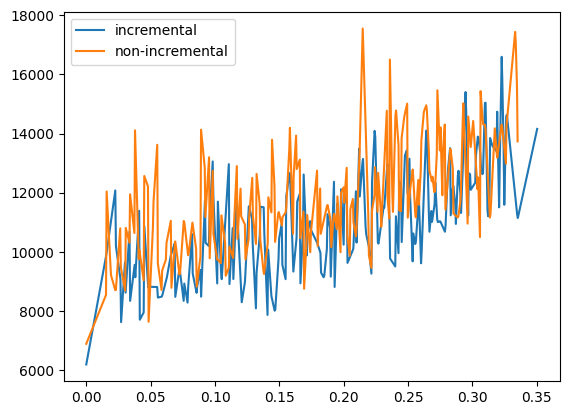

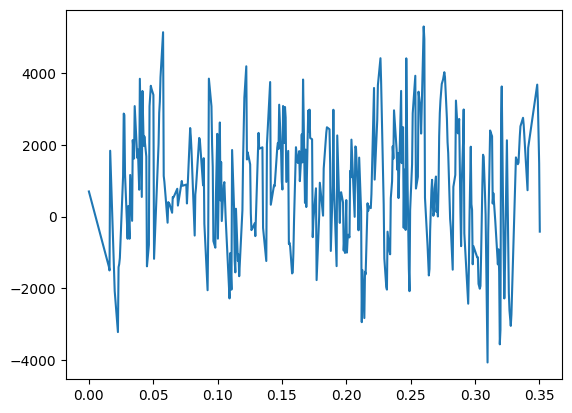

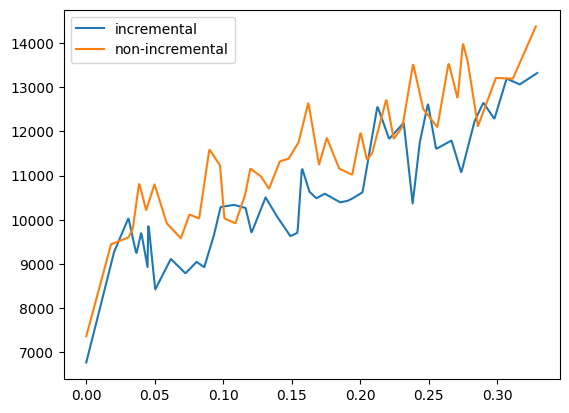

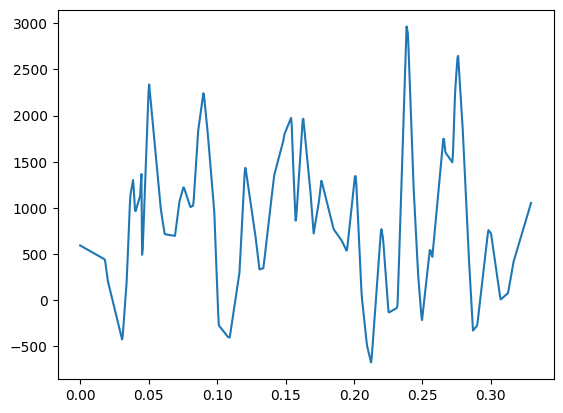

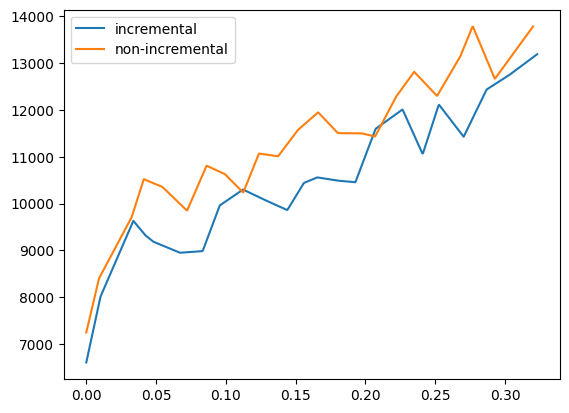

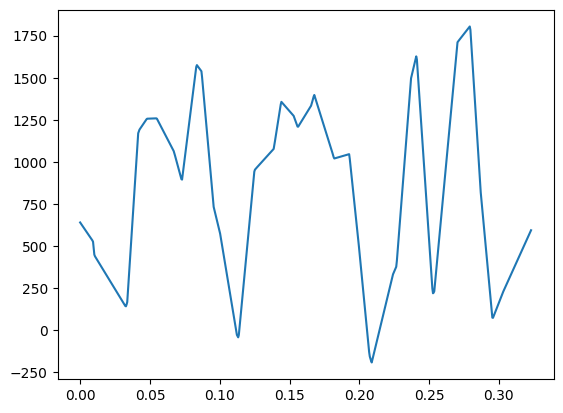

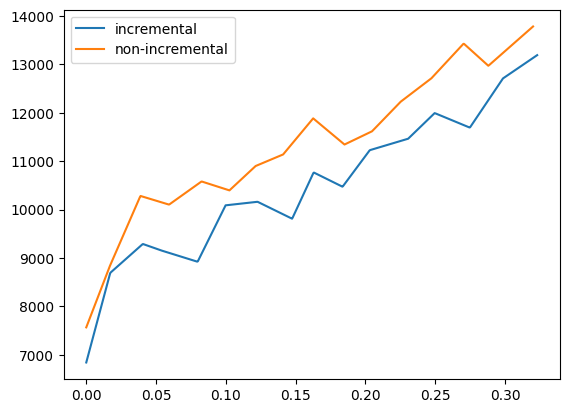

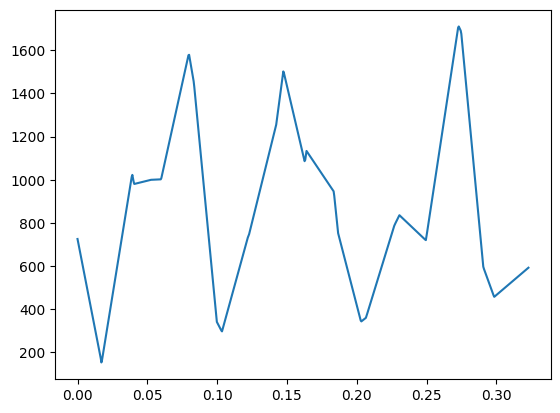

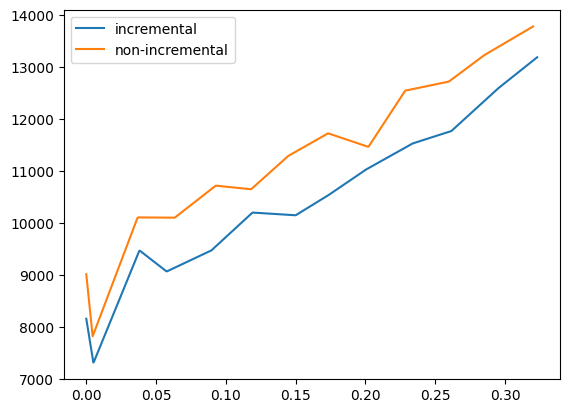

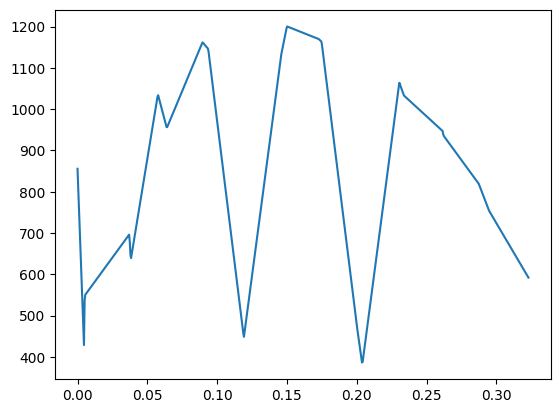

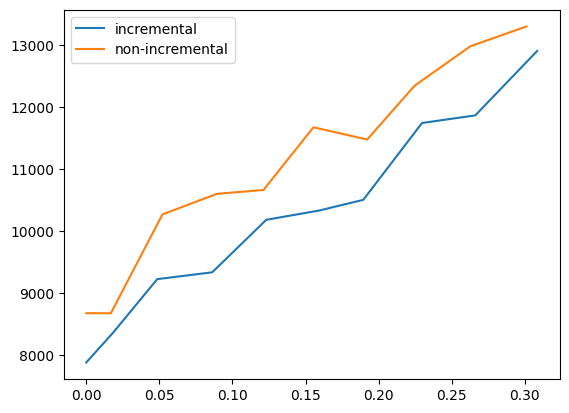

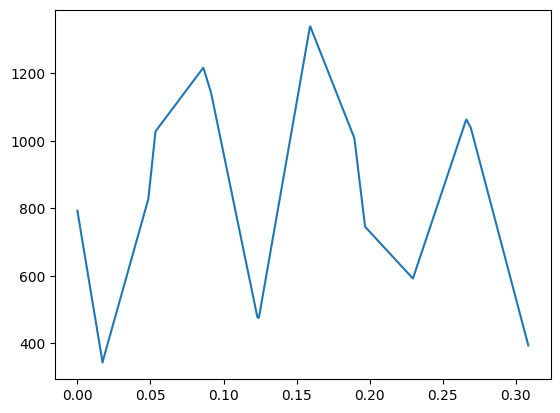

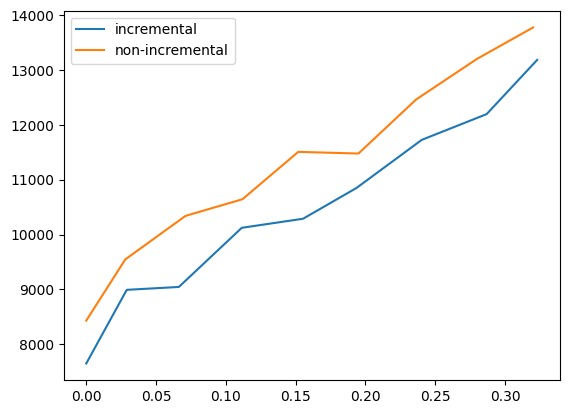

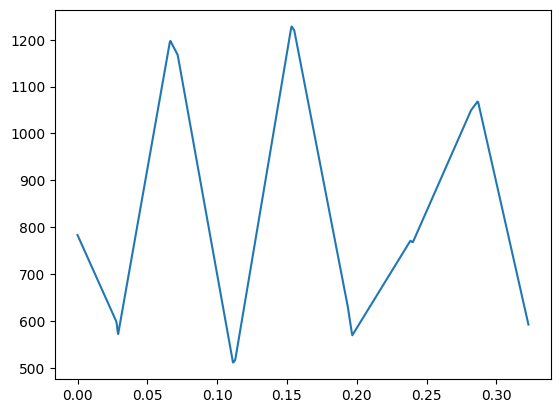

In [4]:
import json 
import glob
import matplotlib.pyplot as plt
import numpy as np
import pprint
from math import sqrt
from scipy.interpolate import interp1d

def get_data(file_name):
    fh = open(file_name)
    data = json.load(fh)
    fh.close()
    return data

def mean_value(values):
    return sum(values)/len(values)

def std_dev(values, mean):
    return sqrt(sum([(val-mean)**2 for val in values])/len(values))

def estimation(fail_ratios,durations,pba):
    x=np.array(fail_ratios)
    y=np.array(durations)
    coefs = np.polyfit(x, y, deg=1)
    return coefs[1]+ coefs[0]*pba

def fail_ratio(dic):
    return dic['statistics']['failure']['total']/(dic['statistics']['failure']['total']+len([x for x in dic['statistics']['success']['durations'] if x !=0]))

f_names = glob.glob("var_pba_256/inc/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['WORKER_REQUEST_FAILURE_PROBABILITY'])
data ={'inc_w' : [sorted([[dic['statistics']['failure']['total'],len([x for x in dic['statistics']['success']['durations'] if x !=0]), dic['duration']] for dic in d['result']['3000000']], key=lambda x:  x[0]/(x[0]+x[1])) for d in tests ],
    'inc_t': sorted([[dic['statistics']['failure']['total'],len([x for x in dic['statistics']['success']['durations'] if x !=0]), dic['duration']] for d in tests for dic in d['result']['3000000']], key=lambda x: x[0]/(x[0]+x[1]))}
f_names = glob.glob("var_pba_256/ninc/*.json")
tests = sorted([get_data(name) for name in f_names], key=lambda d: d['environment']['WORKER_REQUEST_FAILURE_PROBABILITY'])
data['ninc_w']=[sorted([[dic['statistics']['failure']['total'],len([x for x in dic['statistics']['success']['durations'] if x !=0]), dic['duration']] for dic in d['result']['3000000']], key=lambda x:  x[0]/(x[0]+x[1])) for d in tests ]
data['ninc_t']= sorted([[dic['statistics']['failure']['total'],len([x for x in dic['statistics']['success']['durations'] if x !=0]), dic['duration']] for d in tests for dic in d['result']['3000000']], key=lambda x: x[0]/(x[0]+x[1]))

def print_means(inc,ninc, name):
    x = [mean_value([v[0]/(v[0]+v[1]) for v in t]) for t in inc]
    y = [mean_value([v[2] for v in t]) for t in inc]
    f = interp1d(x, y, kind='linear')
    ax = np.linspace(min(x), max(x) , num=700)
    fy = f(ax)
    plt.plot(ax, fy, '-', label = 'incremental')
    x = [mean_value([v[0]/(v[0]+v[1]) for v in t]) for t in ninc]
    y = [mean_value([v[2] for v in t]) for t in ninc]
    f = interp1d(x, y, kind='linear')
    ax = np.linspace(min(x), max(x) , num=700)
    fy = f(ax)
    plt.plot(ax, fy, '-', label = 'non-inccremental')
    plt.legend(loc="upper left")
    plt.savefig('var_pba_256/'+name+'.png')
    plt.show()
    plt.close()
def print_real(inc,ninc, name):
    xi = [sum([v[0] for v in t])/sum([v[0]+v[1] for v in t]) for t in inc]
    yi = [mean_value([v[2] for v in t]) for t in inc]
    fi = interp1d(xi, yi, kind='linear')
    axi = np.linspace(min(xi), max(xi) , num=700)
    fyi = fi(axi)
    plt.plot(axi, fyi, '-', label = 'incremental')
    xn = [sum([v[0] for v in t])/sum([v[0]+v[1] for v in t]) for t in ninc]
    yn = [mean_value([v[2] for v in t]) for t in ninc]
    fn = interp1d(xn, yn, kind='linear')
    axn = np.linspace(min(xn), max(xn) , num=700)
    fyn = fn(axn)
    plt.plot(axn, fyn, '-', label = 'non-incremental')
    plt.legend(loc="upper left")
    plt.savefig('var_pba_256/'+name+'.png')
    plt.show()
    plt.close()
    gy=fn(axn)-fi(axi)
    plt.plot(axi, gy, '-')
    plt.savefig('var_pba_256/delta_'+name+'.png')
    plt.show()
    plt.close()
#print_means(data['inc_w'], data['ninc_w'], 'mean_mean')
#print_real(data['inc_w'], data['ninc_w'], 'real_mean')
def chunks(xs, n):
    n = max(1, n)
    return [xs[i:i+n] for i in range(0, len(xs), n)]

#print_means(chunks(data['inc_t'],10), chunks(data['ninc_t'],10), 'mean_10')
for n in range(0,49,7):
    print_real(chunks(data['inc_t'],n), chunks(data['ninc_t'],n), 'real_'+str(n))